In [1]:
import astropy.units as u
import numpy as np
from astropy.modeling.blackbody import blackbody_nu
from scipy.integrate import quad
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
%matplotlib inline

def draw_telescope(telescope):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # make the reciever look like a box
    box = np.random.uniform(-1, 1, size=(1000, 3))
    box[:, 2] += telescope.focal_length

    positions = telescope.huygens_antennas_positions
    x = positions[:, 0]
    y = positions[:, 1]
    z = positions[:, 2]

    ax.scatter(x, y, z, color='gray', s=0.1)
    ax.scatter(box[:, 0], box[:, 1], box[:, 2], color='black', s=0.1)

#### Very simplistic background approximation
Lets build a telescope in the vacuum of space. Just so I can neglect any atmospheric absorption.

One source of background noise in the antenna of a radio telescope is the blackbody radiation of the cosmic mircowave background.

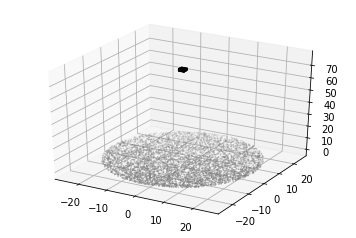

In [2]:
from imaging_atmospheric_askaryan_telescope import telescope
focal_length = 75
draw_telescope(telescope.ImagingReflector(focal_length = focal_length))

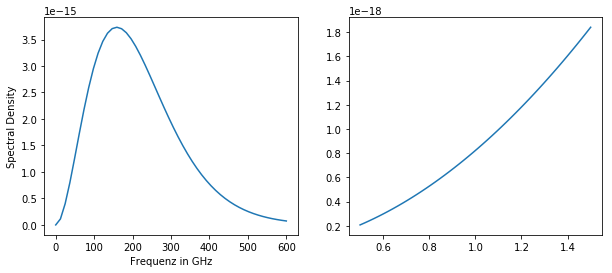

In [3]:
bandwidth = np.linspace(0.5, 1.5) *u.GHz
T = 2.7 * u.K

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))
f = np.linspace(0.1, 600) *u.GHz

ax1.plot(f, blackbody_nu(f, T))
ax2.plot(bandwidth, blackbody_nu(bandwidth, T))
ax1.set_xlabel('Frequenz in GHz')
ax1.set_ylabel('Spectral Density')

In [4]:
spectral_density, _ = quad(lambda x : blackbody_nu(x, T).si.value, bandwidth[0].si.value, bandwidth[-1].si.value)
spectral_density = spectral_density * u.Unit('erg/(cm^2 s sr)')
spectral_density

<Quantity 8.89481925e-13 erg / (cm2 s sr)>

The power deposited into the reflector from the cosmic microwave background. 
I assume the telescope has a field of view of 4.5 degrees. That means all energy from that solid angle gets deposited into the sensor area if the reflectivity of the dish is 100%.

In [5]:
dish_area = 2*np.pi*(12.5 * u.m)**2
fov = 4.5 * u.deg

solid_angle = (2 * np.pi * (1 - np.cos(4.5 * u.deg))) * u.sr

power = (spectral_density * dish_area * solid_angle).to('Watt')

within the duration of one sample, which I assume to be like a nano second or so, we deposit the following total energy into the sensor area.

In [6]:
sample_length = 1 * u.ns
energy_deposited = power * sample_length
energy_deposited.to('Joule')

<Quantity 1.6913886e-23 J>

__Signal Strength Approximation__

Let's pretend the signal from the air shower is an incident plane wave with an amplitude of 25 micro Volt per meter into the sensor. 

In [7]:
E_max = 25 *u.Unit('mV/m')
A_sensor = (0.5 * u.m)**2

z = (377*u.Ohm) # free space impedance.
S = 0.5 * 1/(377*u.Ohm) * (E_max**2) * A_sensor * sample_length
print('Signal energy:')
S.to('joule')

Signal energy:


<Quantity 2.07228117e-16 J>